In [1]:
import pandas as pd
import sqlite3
import json
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

from tqdm.auto import tqdm
tqdm.pandas()

db_path = r"C:\sqlite3\chess.db"
conn = sqlite3.connect(db_path)
cursor = conn.cursor()
df = pd.read_sql_query("SELECT * FROM clock", conn)
conn.close()

In [2]:
df.head()

,uid,seconds
0,1,"[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178..."
1,2,"[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177..."
2,3,"[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178..."
3,4,"[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173..."
4,5,"[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180..."


In [ ]:
# data\input\100wuid.csv
# df.to_csv(r'..\..\data\input\clock_info.csv', index=False)

In [4]:
df['seconds'].values
#str形式的，要转成真list

array(['[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178.6, 176.5, 178.7, 176.5, 178.0, 176.1, 177.3, 174.2, 177.3, 174.2, 176.4, 174.4, 175.3, 173.6, 175.0, 172.6, 174.1, 172.2, 173.6, 170.6]',
       '[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177.7, 178.0, 177.6, 176.6, 177.9, 175.9, 177.1, 173.2, 176.8, 164.7, 173.4, 164.9, 170.2, 152.3, 167.5, 148.0, 165.0, 147.6, 158.4, 146.3, 157.5]',
       '[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178.1, 177.1, 179.0, 173.1, 175.2, 172.0, 174.9, 171.9, 175.1, 172.4, 172.3, 172.1, 171.1, 171.1, 170.9, 167.7, 171.8, 165.6, 169.5, 165.1, 153.2, 156.2, 152.9, 155.9, 148.9, 151.7, 149.8, 149.7, 137.4, 142.1, 135.3, 131.7, 132.7]',
       ...,
       '[180.9, 178.9, 180.5, 178.3, 179.3, 178.6, 179.3, 178.1, 178.5, 177.0, 176.5, 170.9, 176.6, 170.1, 170.5, 167.5, 167.0, 164.9, 164.7, 153.8, 164.6, 154.0, 165.5, 153.2, 155.5, 151.1, 156.4, 150.9, 154.7, 141.0, 153.9, 126.5, 150.8, 112.0, 144.6, 109.6, 134.4, 108.0, 128.9, 103.0, 127.0, 94.8, 124.6, 88

In [5]:
df['second_list'] = df['seconds'].progress_apply(ast.literal_eval)
df.head()

  0%|          | 0/1017708 [00:00<?, ?it/s]

,uid,seconds,second_list
0,1,"[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178..."
1,2,"[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177..."
2,3,"[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178..."
3,4,"[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173..."
4,5,"[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180..."


split "seconds" into white/black 's perspective

In [6]:
def split_white_black(sec_list):
    white = sec_list[::2]
    black = sec_list[1::2]
    return white, black
# sec_list = [1,2,3,4,5,6,7,8]
# print(split_white_black(sec_list))
df[['white_sec', 'black_sec']] = (df['second_list'].progress_apply(lambda x: pd.Series(split_white_black(x))))
# df = df.drop(columns=['white_sec', 'black_sec', 'seconds_list'])

  0%|          | 0/1017708 [00:00<?, ?it/s]

In [7]:
df.head()

,uid,seconds,second_list,white_sec,black_sec
0,1,"[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 179.1, 179.4, 178.6, 178.7, 178.0, 177...","[178.3, 178.0, 177.2, 176.5, 176.5, 176.1, 174..."
1,2,"[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 178.5, 178.3, 177.7, 177.6, 177.9, 177...","[179.1, 178.5, 178.2, 178.0, 176.6, 175.9, 173..."
2,3,"[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 180.4, 180.5, 178.1, 179.0, 175.2, 174...","[178.3, 177.0, 177.1, 177.1, 173.1, 172.0, 171..."
3,4,"[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.2, 173.9, 173.9, 167.6, 166.7, 161...","[179.3, 174.2, 174.0, 173.9, 171.7, 171.4, 170..."
4,5,"[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 180.9, 181.0, 180.2, 179.9, 180.8, 181...","[177.1, 173.7, 172.2, 170.7, 170.0, 170.1, 165..."


"second_list" distribution

In [8]:
all_seconds = []
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Collecting all secondsa"):
    sec_list = row['second_list']
    all_seconds.extend(sec_list)
print(f"total length:{len(all_seconds)}")
print(f"seconds' range:{min(all_seconds)}~{max(all_seconds)}")

total length:88912060
seconds' range:0.1~638.8


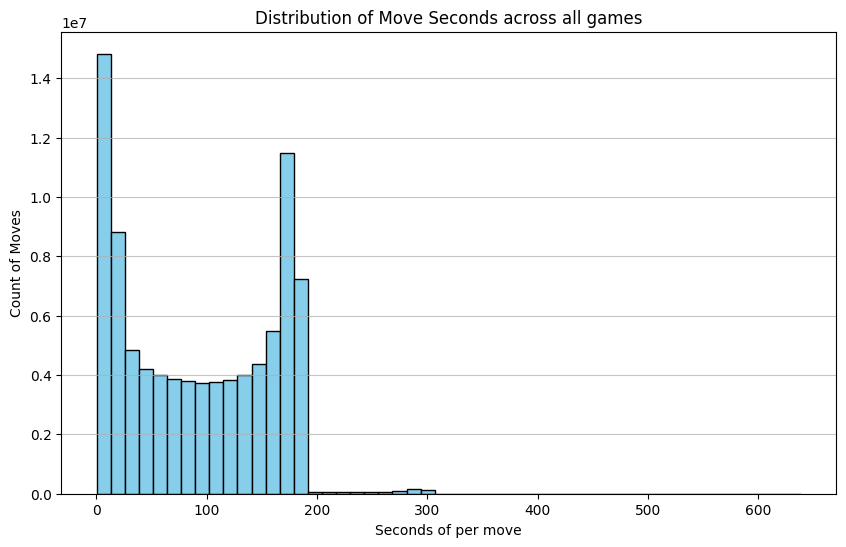

In [9]:
all_seconds_serise = pd.Series(all_seconds)
plt.figure(figsize=(10, 6))
plt.hist(all_seconds, bins=50, color="skyblue", edgecolor = 'black')
plt.title("Distribution of Move Seconds across all games")
plt.xlabel("Seconds of per move")
plt.ylabel("Count of Moves")
plt.grid(axis='y', alpha=0.75)
plt.show()

In [10]:
os.makedirs(r"..\..\data\input", exist_ok=True)
df.to_csv(r'..\..\data\input\clock_info.csv', index=False)

In [11]:
#确定seconds的分位数分布
quantiles = all_seconds_serise.quantile([0.1, 0.25, 0.5, 0.75, 0.9])
print(quantiles)

0.10      7.1
0.25     22.5
0.50     89.8
0.75    160.0
0.90    178.4
dtype: float64


In [3]:
# 把clock_info.csv重新写入数据库
import pandas as pd
import numpy as np
import sqlite3
csv_path2 = r"..\..\data\input\clock_info.csv"
db_path = r"C:\sqlite3\chess.db"
table_name = "clock"
df2 = pd.read_csv(csv_path2)
conn = sqlite3.connect(db_path)
df2.to_sql(table_name, conn, if_exists="replace", index=False)
conn.close()

In [4]:
df2.head()

,uid,seconds,second_list,white_sec,black_sec
0,1,"[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 179.1, 179.4, 178.6, 178.7, 178.0, 177...","[178.3, 178.0, 177.2, 176.5, 176.5, 176.1, 174..."
1,2,"[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 178.5, 178.3, 177.7, 177.6, 177.9, 177...","[179.1, 178.5, 178.2, 178.0, 176.6, 175.9, 173..."
2,3,"[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 180.4, 180.5, 178.1, 179.0, 175.2, 174...","[178.3, 177.0, 177.1, 177.1, 173.1, 172.0, 171..."
3,4,"[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.2, 173.9, 173.9, 167.6, 166.7, 161...","[179.3, 174.2, 174.0, 173.9, 171.7, 171.4, 170..."
4,5,"[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 180.9, 181.0, 180.2, 179.9, 180.8, 181...","[177.1, 173.7, 172.2, 170.7, 170.0, 170.1, 165..."


In [13]:
df2['white_sec'].values

array(['[180.1, 179.1, 179.4, 178.6, 178.7, 178.0, 177.3, 177.3, 176.4, 175.3, 175.0, 174.1, 173.6]',
       '[179.4, 178.5, 178.3, 177.7, 177.6, 177.9, 177.1, 176.8, 173.4, 170.2, 167.5, 165.0, 158.4, 157.5]',
       '[179.9, 180.4, 180.5, 178.1, 179.0, 175.2, 174.9, 175.1, 172.3, 171.1, 170.9, 171.8, 169.5, 153.2, 152.9, 148.9, 149.8, 137.4, 135.3, 132.7]',
       ...,
       '[180.9, 180.5, 179.3, 179.3, 178.5, 176.5, 176.6, 170.5, 167.0, 164.7, 164.6, 165.5, 155.5, 156.4, 154.7, 153.9, 150.8, 144.6, 134.4, 128.9, 127.0, 124.6, 118.9, 119.8, 110.5, 110.0, 108.4, 94.4, 92.8, 91.3, 90.2, 80.8, 75.0, 75.2, 59.0, 56.6, 54.3, 48.5, 48.3, 45.4, 45.1, 38.5, 36.1, 32.3, 30.3, 29.7, 26.8, 25.5, 23.0, 20.1, 20.4, 20.5, 17.1, 16.7, 17.0, 14.8, 11.5, 11.0, 11.4, 5.2, 5.5, 3.8, 3.8, 3.9, 3.1, 3.6, 4.0, 1.7, 2.2, 2.6, 2.2, 2.8, 3.2, 3.4, 3.2, 3.2, 2.2, 2.7, 2.6, 3.5, 3.6, 3.9]',
       '[180.9, 168.0, 164.3, 164.2, 164.0, 163.6, 164.1, 163.4, 163.7, 163.4, 130.5, 124.6, 121.6, 117.9, 115.6, 115.2

In [ ]:
import ast
from tqdm.auto import tqdm
tqdm.pandas()
def compute_durations(time_series):
    if not time_series:
        return []
    if isinstance(time_series, str):
        times = ast.literal_eval(time_series)
    else:
        times = list(time_series)
    
    durations = []
    for i, t in enumerate(times):
        if i==0:
            continue
        else:
            durations.append(round(times[i-1] - times[i], 1))
    return durations
df2['white_durations'] = df2['white_sec'].progress_apply(compute_durations)
df2['black_durations'] = df2['black_sec'].progress_apply(compute_durations)
df2.head()

  0%|          | 0/1017708 [00:00<?, ?it/s]

  0%|          | 0/1017708 [00:00<?, ?it/s]

,uid,seconds,second_list,white_sec,black_sec,white_durations,black_durations
0,1,"[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 179.1, 179.4, 178.6, 178.7, 178.0, 177...","[178.3, 178.0, 177.2, 176.5, 176.5, 176.1, 174...","[1.0, -0.3, 0.8, -0.1, 0.7, 0.7, 0.0, 0.9, 1.1...","[0.3, 0.8, 0.7, 0.0, 0.4, 1.9, 0.0, -0.2, 0.8,..."
1,2,"[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 178.5, 178.3, 177.7, 177.6, 177.9, 177...","[179.1, 178.5, 178.2, 178.0, 176.6, 175.9, 173...","[0.9, 0.2, 0.6, 0.1, -0.3, 0.8, 0.3, 3.4, 3.2,...","[0.6, 0.3, 0.2, 1.4, 0.7, 2.7, 8.5, -0.2, 12.6..."
2,3,"[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 180.4, 180.5, 178.1, 179.0, 175.2, 174...","[178.3, 177.0, 177.1, 177.1, 173.1, 172.0, 171...","[-0.5, -0.1, 2.4, -0.9, 3.8, 0.3, -0.2, 2.8, 1...","[1.3, -0.1, 0.0, 4.0, 1.1, 0.1, -0.5, 0.3, 1.0..."
3,4,"[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.2, 173.9, 173.9, 167.6, 166.7, 161...","[179.3, 174.2, 174.0, 173.9, 171.7, 171.4, 170...","[0.2, 5.3, 0.0, 6.3, 0.9, 5.3, -0.1, 14.8, 9.4...","[5.1, 0.2, 0.1, 2.2, 0.3, 0.9, 1.5, 4.3, 4.5, ..."
4,5,"[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 180.9, 181.0, 180.2, 179.9, 180.8, 181...","[177.1, 173.7, 172.2, 170.7, 170.0, 170.1, 165...","[0.0, -0.1, 0.8, 0.3, -0.9, -0.5, 3.4, 0.6, 0....","[3.4, 1.5, 1.5, 0.7, -0.1, 5.1, 4.6, 5.5, 3.6,..."


In [25]:
# check how much is not right(time back)
white_nums_all = df2['white_durations'].explode()
black_nums_all = df2['black_durations'].explode()
all_durations = pd.concat([white_nums_all, black_nums_all], ignore_index=True)
all_durations = all_durations.dropna().astype(float)
total_count = len(all_durations)
negative_count = (all_durations<0).sum()
negative_ratio = negative_count/total_count
print(f"total count:{total_count},\ntime-reversal observations(<0):{negative_count},\ntime-reversal proportion:{negative_ratio}")

total count:86892474,
time-reversal observations(<0):20662877,
time-reversal proportion:0.23779823555259802


In [26]:
df2.to_csv(r'..\..\data\input\clock_info.csv', index=False)

In [34]:
conn = sqlite3.connect(db_path)
df2['white_durations'] = df2['white_durations'].progress_apply(str)
df2['black_durations'] = df2['black_durations'].progress_apply(str)
df2.to_sql(table_name, conn, if_exists="replace", index=False)
conn.close()

  0%|          | 0/1017708 [00:00<?, ?it/s]

  0%|          | 0/1017708 [00:00<?, ?it/s]

In [30]:
df2 = df2.drop(columns=['white_durations', 'black_durations'])

In [35]:
df2.head()

,uid,seconds,second_list,white_sec,black_sec,white_durations,black_durations
0,1,"[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 179.1, 179.4, 178.6, 178.7, 178.0, 177...","[178.3, 178.0, 177.2, 176.5, 176.5, 176.1, 174...","[1.0, -0.3, 0.8, -0.1, 0.7, 0.7, 0.0, 0.9, 1.1...","[0.3, 0.8, 0.7, 0.0, 0.4, 1.9, 0.0, -0.2, 0.8,..."
1,2,"[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 178.5, 178.3, 177.7, 177.6, 177.9, 177...","[179.1, 178.5, 178.2, 178.0, 176.6, 175.9, 173...","[0.9, 0.2, 0.6, 0.1, -0.3, 0.8, 0.3, 3.4, 3.2,...","[0.6, 0.3, 0.2, 1.4, 0.7, 2.7, 8.5, -0.2, 12.6..."
2,3,"[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 180.4, 180.5, 178.1, 179.0, 175.2, 174...","[178.3, 177.0, 177.1, 177.1, 173.1, 172.0, 171...","[-0.5, -0.1, 2.4, -0.9, 3.8, 0.3, -0.2, 2.8, 1...","[1.3, -0.1, 0.0, 4.0, 1.1, 0.1, -0.5, 0.3, 1.0..."
3,4,"[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.2, 173.9, 173.9, 167.6, 166.7, 161...","[179.3, 174.2, 174.0, 173.9, 171.7, 171.4, 170...","[0.2, 5.3, 0.0, 6.3, 0.9, 5.3, -0.1, 14.8, 9.4...","[5.1, 0.2, 0.1, 2.2, 0.3, 0.9, 1.5, 4.3, 4.5, ..."
4,5,"[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 180.9, 181.0, 180.2, 179.9, 180.8, 181...","[177.1, 173.7, 172.2, 170.7, 170.0, 170.1, 165...","[0.0, -0.1, 0.8, 0.3, -0.9, -0.5, 3.4, 0.6, 0....","[3.4, 1.5, 1.5, 0.7, -0.1, 5.1, 4.6, 5.5, 3.6,..."


In [36]:
conn = sqlite3.connect(db_path)
df2.to_sql(table_name, conn, if_exists="replace", index=False)
conn.close()